In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

/home/ssuarez/tutorials/pytorch_tutorial/.env/lib/python3.9/site-packages/torch/autograd/__init__.py:394: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  result = Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [0/60000], Loss: 1484.031494140625
Epoch [1000/60000], Loss: 1.002394437789917
Epoch [2000/60000], Loss: 0.9980915784835815
Epoch [3000/60000], Loss: 0.9972898364067078
Epoch [4000/60000], Loss: 0.9970011115074158
Epoch [5000/60000], Loss: 0.9974572658538818
Epoch [6000/60000], Loss: 0.9964881539344788
Epoch [7000/60000], Loss: 0.9963158369064331
Epoch [8000/60000], Loss: 0.9962027072906494
Epoch [9000/60000], Loss: 0.9960907101631165
Epoch [10000/60000], Loss: 0.9959972500801086
Epoch [11000/60000], Loss: 0.9960118532180786
Epoch [12000/60000], Loss: 0.9960143566131592
Epoch [13000/60000], Loss: 0.9958482384681702
Epoch [14000/60000], Loss: 0.9957422018051147
Epoch [15000/60000], Loss: 0.9959085583686829
Epoch [16000/60000], Loss: 0.9955206513404846
Epoch [17000/60000], Loss: 0.9965609908103943
Epoch [18000/60000], Loss: 0.9958348274230957
Epoch [19000/60000], Loss: 0.995378851890564
Epoch [20000/60000], Loss: 0.9949613213539124
Epoch [21000/60000], Loss: 0.9941977262496948
Epoc

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


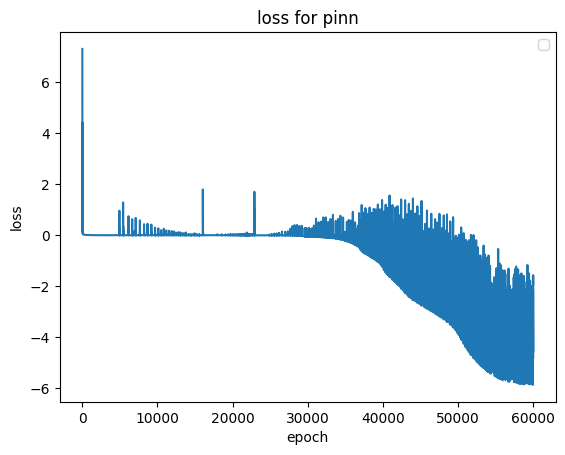

In [2]:


# parameters
ZETTA = 0.2
W = 10

# initial conditions
X0 = 1
X_T_0 = 0

# Define the PINN model
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50),   # Input layer with 1 feature
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 50),  # Hidden layer
            nn.Tanh(),
            nn.Linear(50, 1),    # Output layer for v(t)
        )

    def forward(self, t):
        return self.net(t)

# Define the Poisson equation loss function
def damped_oscillatior_loss(model, t):
    x = model(t)
    x_t = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)[0]
    x_tt = torch.autograd.grad(x_t, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    f = (x_tt + (2*ZETTA*W)*x_t + (W**2)*x)**2  # Poisson equation: u_xx = 1
    t_0 = torch.tensor([0.0], requires_grad=True)
    x_0 = model(t_0)
    initial_conditions = (x_0 - X0)**2
    x_t_0 = torch.autograd.grad(x_0, t_0, grad_outputs=torch.ones_like(x_0), create_graph=True)[0]
    initial_conditions_der = (x_t_0 - X_T_0)**2
    return torch.mean(f) + \
        torch.mean(initial_conditions) + \
        torch.mean(initial_conditions_der)
        # (-0.0629 - model(torch.tensor([0.4848])))**2 + \
        # (-0.5183 - model(torch.tensor([0.3030])))**2 + \
        # (0.2595 - model(torch.tensor([0.6061])))**2

# Training data
t = 2*torch.rand(100, 1)  # Randomly sampled points in [0, 1]
t.requires_grad = True

# Create PINN model
model = PINN()

optimizer = optim.Adam(params=model.parameters(), lr=1e-3)

# loss tracking
losses = []

# Training loop
epochs = 60000
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Compute the loss
    loss = damped_oscillatior_loss(model, t)
    
    # Backpropagation
    loss.backward()
    losses.append(torch.log(loss).item())
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item()}")


import matplotlib.pyplot as plt
plt.figure()
plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss for pinn')
plt.legend()
plt.show()

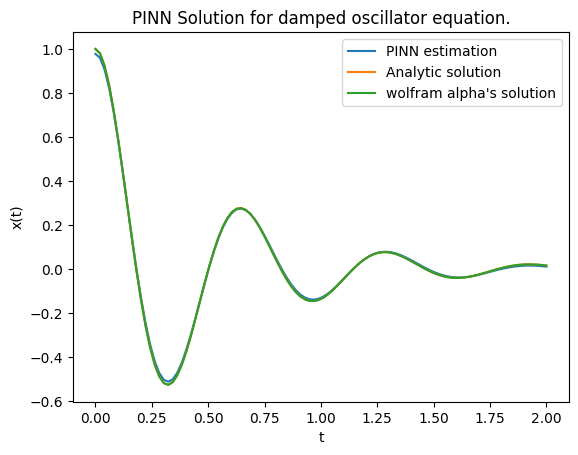

In [3]:
# Test the model
t_test = 2*torch.linspace(0, 1, 100).reshape(-1, 1)
x_test = model(t_test)
Z = ZETTA
w = W
root = torch.sqrt(torch.tensor([Z**2 - 1], dtype=torch.cfloat))
x_real = X0*torch.exp(-w*Z*t_test)*(torch.cosh(w*root*t_test) + (Z/root)*torch.sinh(w*root*t_test))
x_real = x_real.real

# wolfram alpha's solution:
six = torch.tensor([6.0])
x_sth = (1/12)*torch.exp(-2*t_test)*(torch.sqrt(six)*torch.sin(4*torch.sqrt(six)*t_test) + 12*torch.cos(4*torch.sqrt(six)*t_test))


# Plot the results
import matplotlib.pyplot as plt
plt.figure()
plt.plot(t_test.detach().numpy(), x_test.detach().numpy(), label="PINN estimation")
plt.plot(t_test.detach().numpy(), x_real.detach().numpy(), label="Analytic solution")
plt.plot(t_test.detach().numpy(), x_sth.detach().numpy(), label="wolfram alpha's solution")
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('PINN Solution for damped oscillator equation.')
plt.legend()
plt.show()

It appears that a certain net can only convert to a certain estimate solution to
the differential equation. Maybe it seems that the expresivity of the net is
too restricted by its architecture?

Different architectures tend to converge to different things, but none of those
is too good to get confused with the actual solution. I think that the
differential equation tends to give "local" information, so each little interval
around a point verifies the differential equation, but not necesarily the same
initial conditions.

I believe (for now) in that. The neural network solves "locally" the initial
condition problem, but for distant points, the initial condition does not work
that much anymore.

More points on the domain of the target function does not seem to improve the
performance of the PINN.

More data (measurements) on the domain of the target function seem to modify
immensly the solution to the given differential equation.

I was trying to optimize the intput parameters of the neural network in this
example, due to chatGPT's suggestion. But prompting chatGPT again why the
optimization was done on this also, it retracted. Tried without those, and a
different lr, and the solution converged much more nicely to the proper solution
of the differential equation. This convergence was with 40 000 epochs, and may
have been a little due to luck?

In the last epochs, the loss does decrease significantly, gonna try with much
more. Yep, it converges to a more precise solution, results in the graph above.


